# 02 — LightGBM WFO (v5): Feature-Selected Walk-Forward Optimization

**Extends:** `02_lgbm_omni_0fee_v3.ipynb` (WFO structure) + `05_feature_selection_lgbm_v1.py` (selection pipeline)  
**Target:** Fixed Horizon — 1 if 6h forward return > 0.3% (pre-labelled in V1 features)  
**Features:** V1 (195-feature pool from 1h OHLCV) + V3 (21 external features)  
**Artifacts:** `artifacts/02_lgbm_omni_0fee_v5/`  

## Phases

| Phase | Description |
|-------|-------------|
| 1 | 4-stage feature selection: Variance+Corr → MI Top-60 → Stability → Permutation prune |
| 2 | Walk-Forward Optimization: 4 schemes (EXP / L2Y / M1Y / S3M) |
| 3 | Compact grid search on best WFO scheme (16 combos) |
| 4 | Long-only backtesting with ATR-based limit/SL/TP (0-fee) |
| 5 | Professional-grade visualizations (TCN v5 style) |

## WFO Schemes

| ID | Name | Train window |
|----|------|--------------|
| EXP | Expanding | All past data |
| L2Y | 2-Year Sliding | 17,520 bars (24 mo) |
| M1Y | 1-Year Sliding | 8,760 bars (12 mo) |
| S3M | 3-Month Sliding | 2,160 bars (3 mo) |


In [18]:
import itertools
import json
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350'; GREEN='#26A69A'; PURPLE='#7B1FA2'

# ── WFO constants ─────────────────────────────────────────────────────────────
OOS_START  = pd.Timestamp('2024-01-01')
STEP_SIZE  = 720   # bars per WFO step (~1 month at 1h)
EMBARGO    = 12    # embargo bars (12h = label lookahead)
VAL_FRAC   = 0.20  # last fraction of train window for early stopping

LABEL_COL  = 'label'

# ── Backtest defaults ─────────────────────────────────────────────────────────
DEFAULT_THRESHOLD  = 0.55
DEFAULT_ENTRY_ATR  = 0.30
DEFAULT_SL_MULT    = 1.5
DEFAULT_TP_MULT    = 2.0
DEFAULT_MAX_HOLD   = 48
DEFAULT_COOLDOWN   = 4

# ── Fee model (Binance spot, VIP0) ────────────────────────────────────────────
# Fee model — sourced from lab/notebooks/07_lgbm_grid_v7.ipynb
# Spot longs: limit entry = 0% (free), limit TP = 0%, SL/timeout = 0.05% taker
MAKER_FEE      = 0.0000   # 0%    — limit orders (entry + TP): FREE on Binance Spot
SPOT_TAKER_FEE = 0.0005   # 0.05% — market orders (SL / timeout exits)
BUFFER         = 0.0005   # 5 bp penetration buffer for limit fill confirmation

# ── Feature selection thresholds ──────────────────────────────────────────────
VAR_THRESHOLD    = 1e-6
CORR_THRESHOLD   = 0.85
TOP_K_MI         = 60
FS_WINDOW_SIZE   = 2160
FS_STEP          = 720
MIN_STABLE_FRAC  = 0.50
TOP_K_PER_WINDOW = 35
PERM_THRESHOLD   = 0.0005

print('Imports OK')

Imports OK


In [19]:
def _find_repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / 'pyproject.toml').exists():
            return p
        p = p.parent
    raise RuntimeError('pyproject.toml not found — run from within the repo')

REPO      = _find_repo_root()
RAW_DIR   = REPO / 'data' / 'raw'
FEAT_DIR  = REPO / 'data' / 'features'
ARTS_DIR  = REPO / 'artifacts' / '02_lgbm_omni_0fee_v5'
ARTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Repo root : {REPO}')
print(f'Artifacts : {ARTS_DIR}')

Repo root : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
Artifacts : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/02_lgbm_omni_0fee_v5


---
## Phase 1 — Data Loading & Feature Assembly

In [20]:
# ── V1 features (195 model features + backtest-only cols + label) ─────────────
print('Loading V1 features (BTCUSDT_1h_features.parquet)...')
v1_df = pd.read_parquet(FEAT_DIR / 'BTCUSDT_1h_features.parquet')
v1_df.index = v1_df.index.tz_localize(None) if v1_df.index.tz else v1_df.index

# ── V3 features (21 external features) ────────────────────────────────────────
print('Loading V3 features (BTCUSDT_1h_v3_features.parquet)...')
v3_df = pd.read_parquet(FEAT_DIR / 'BTCUSDT_1h_v3_features.parquet')
v3_df.index = v3_df.index.tz_localize(None) if v3_df.index.tz else v3_df.index

# ── Raw OHLCV (high/low for backtester) ───────────────────────────────────────
print('Loading raw OHLCV (BTCUSDT_1h.parquet)...')
raw_df = pd.read_parquet(
    RAW_DIR / 'BTCUSDT_1h.parquet',
    columns=['open', 'high', 'low', 'close', 'volume'],
)
raw_df.index = raw_df.index.tz_localize(None) if raw_df.index.tz else raw_df.index

# ── Feature registry ──────────────────────────────────────────────────────────
with open(FEAT_DIR / 'feature_registry.json') as f:
    registry = json.load(f)
BACKTEST_COLS = registry['backtest_only_cols']  # ['close', 'sma_200', 'atr_14_pct']

print(f'\nV1 shape : {v1_df.shape}  ({v1_df.index.min().date()} → {v1_df.index.max().date()})')
print(f'V3 shape : {v3_df.shape}  ({v3_df.index.min().date()} → {v3_df.index.max().date()})')
print(f'Raw shape: {raw_df.shape}')
print(f'Backtest-only cols: {BACKTEST_COLS}')

Loading V1 features (BTCUSDT_1h_features.parquet)...
Loading V3 features (BTCUSDT_1h_v3_features.parquet)...
Loading raw OHLCV (BTCUSDT_1h.parquet)...

V1 shape : (74366, 199)  (2017-11-15 → 2026-05-16)
V3 shape : (76938, 21)  (2017-08-17 → 2026-05-27)
Raw shape: (76938, 5)
Backtest-only cols: ['close', 'sma_200', 'atr_14_pct']


In [21]:
# Derive column lists
V1_FEATURE_COLS = [c for c in v1_df.columns if c not in BACKTEST_COLS + [LABEL_COL]]
V3_FEATURE_COLS = list(v3_df.columns)

print(f'V1 model features  : {len(V1_FEATURE_COLS)}')
print(f'V3 model features  : {len(V3_FEATURE_COLS)}')
print(f'V3 feature names   : {V3_FEATURE_COLS}')

# Merge: V1 base (has label + backtest_only_cols), add V3, add high/low
merged = v1_df.copy()
for col in v3_df.columns:
    merged[col] = v3_df[col].reindex(merged.index)

# Add high / low for backtester (not used as model features)
merged['high'] = raw_df['high'].reindex(merged.index)
merged['low']  = raw_df['low'].reindex(merged.index)

# Drop rows without label (forward-looking label is NaN at tail)
merged.dropna(subset=[LABEL_COL], inplace=True)

ALL_FEATURE_COLS = V1_FEATURE_COLS + V3_FEATURE_COLS

print(f'\nCombined feature pool : {len(ALL_FEATURE_COLS)} ({len(V1_FEATURE_COLS)} V1 + {len(V3_FEATURE_COLS)} V3)')
print(f'Merged rows           : {len(merged):,}')
print(f'Date range            : {merged.index.min().date()} → {merged.index.max().date()}')
print(f'Label positive rate   : {merged[LABEL_COL].mean():.3f}')

oos_mask = merged.index >= OOS_START
print(f'OOS bars (≥2024-01-01): {oos_mask.sum():,}')

V1 model features  : 195
V3 model features  : 21
V3 feature names   : ['cross_eth_btc_ratio', 'cross_eth_btc_mom_24h', 'cross_eth_btc_mom_72h', 'cross_altcoin_breadth_24h', 'cross_btc_relative_strength', 'cross_alt_correlation_24h', 'mkt_btc_dominance', 'mkt_btc_dominance_chg_7d', 'mkt_eth_dominance', 'mkt_total_mcap_chg_24h', 'mkt_stablecoin_pct', 'sent_fear_greed', 'sent_fear_greed_ma7', 'sent_fear_greed_chg_7d', 'micro_amihud_illiq', 'micro_kyle_lambda', 'micro_roll_spread', 'micro_volume_clock', 'vol_term_structure', 'mom_normalized_24h', 'mom_normalized_72h']

Combined feature pool : 216 (195 V1 + 21 V3)
Merged rows           : 74,366
Date range            : 2017-11-15 → 2026-05-16
Label positive rate   : 0.509
OOS bars (≥2024-01-01): 20,785


---
## Phase 1 — Feature Selection (4-Stage Pipeline)

Selects ~13 features from the 216-feature pool on **pre-OOS training data only**.

| Stage | Method | Typical survivors |
|-------|--------|-------------------|
| 1 | Variance (>1e-6) + Spearman ρ < 0.85 | ~120 |
| 2 | MI top-60 | 60 |
| 3 | Walk-forward stability ≥50% | ~25 |
| 4 | Permutation importance > 0.0005 | ~13 |

In [22]:
# Feature selection uses pre-OOS data only (no data leakage)
train_sel = merged[~oos_mask].copy()
print(f'Feature selection on: {len(train_sel):,} bars')
print(f'  {train_sel.index.min().date()} → {train_sel.index.max().date()}')

# ── STAGE 1: Variance + Spearman correlation filter ───────────────────────────
print('\n' + '='*60)
print('STAGE 1: Variance + Spearman Correlation Filter')
print('='*60)

valid_cols = [
    f for f in ALL_FEATURE_COLS
    if f in train_sel.columns and train_sel[f].notna().sum() > len(train_sel) * 0.50
]
print(f'  Features with >50% non-null: {len(valid_cols)} / {len(ALL_FEATURE_COLS)}')

variances = train_sel[valid_cols].var()
low_var = variances[variances < VAR_THRESHOLD].index.tolist()
candidates = [f for f in valid_cols if f not in low_var]
print(f'  Low-variance removed       : {len(low_var)}')

train_filled = train_sel[candidates].fillna(0)
target_corr  = train_filled.corrwith(train_sel[LABEL_COL], method='spearman').abs()
corr_matrix  = train_filled.corr(method='spearman').abs()

to_drop = set()
for i in range(len(candidates)):
    if candidates[i] in to_drop:
        continue
    for j in range(i + 1, len(candidates)):
        if candidates[j] in to_drop:
            continue
        if corr_matrix.iloc[i, j] > CORR_THRESHOLD:
            keep = (candidates[i]
                    if target_corr.get(candidates[i], 0) >= target_corr.get(candidates[j], 0)
                    else candidates[j])
            drop = candidates[j] if keep == candidates[i] else candidates[i]
            to_drop.add(drop)

stage1 = [f for f in candidates if f not in to_drop]
v3_in_s1 = [f for f in stage1 if f in V3_FEATURE_COLS]
print(f'  Corr-redundant removed     : {len(to_drop)} (ρ > {CORR_THRESHOLD})')
print(f'  Stage 1 survivors          : {len(stage1)}  (V3 in stage1: {len(v3_in_s1)})')

Feature selection on: 53,581 bars
  2017-11-15 → 2023-12-31

STAGE 1: Variance + Spearman Correlation Filter
  Features with >50% non-null: 215 / 216
  Low-variance removed       : 1
  Corr-redundant removed     : 95 (ρ > 0.85)
  Stage 1 survivors          : 119  (V3 in stage1: 14)


In [23]:
# ── STAGE 2: Mutual Information ranking — top 60 ──────────────────────────────
print('STAGE 2: Mutual Information Ranking (top 60)')
print('='*60)

X_s1 = train_sel[stage1].fillna(0).values
y_s1 = train_sel[LABEL_COL].values

t0 = time.time()
mi_scores = mutual_info_classif(X_s1, y_s1, n_neighbors=5, random_state=42)
print(f'  MI computation: {time.time()-t0:.1f}s')

mi_df = pd.DataFrame({
    'feature': stage1,
    'MI':      mi_scores,
    'is_v3':   [f in V3_FEATURE_COLS for f in stage1],
}).sort_values('MI', ascending=False).reset_index(drop=True)

stage2    = mi_df.head(TOP_K_MI)['feature'].tolist()
n_v3_s2   = int(mi_df.head(TOP_K_MI)['is_v3'].sum())
print(f'  Stage 2 survivors: {len(stage2)}  (V3 in top {TOP_K_MI}: {n_v3_s2})')
print('\n  Top 20 features by MI:')
print(mi_df.head(20)[['feature','MI','is_v3']].to_string(index=False))

STAGE 2: Mutual Information Ranking (top 60)
  MI computation: 8.7s
  Stage 2 survivors: 60  (V3 in top 60: 6)

  Top 20 features by MI:
                  feature     MI  is_v3
              bear_streak 0.0065  False
                   ret_2h 0.0063  False
         fib_dist_618_48h 0.0058  False
                 hour_cos 0.0058  False
                   ret_1h 0.0052  False
        vol_price_div_24h 0.0052  False
               stoch_k_14 0.0052  False
          hl_position_48h 0.0051  False
                   ret_3h 0.0048  False
                 ad_z_48h 0.0040  False
        supertrend_dir_30 0.0039  False
                  dom_cos 0.0036  False
              bb_width_50 0.0035  False
          rsi_vol_confirm 0.0035  False
                 skew_24h 0.0035  False
             range_vs_atr 0.0033  False
           close_vs_sma_7 0.0033  False
         close_vs_sma_720 0.0024  False
cross_altcoin_breadth_24h 0.0024   True
       cloud_flip_recency 0.0024  False


In [24]:
# ── STAGE 3: Walk-forward stability ───────────────────────────────────────────
print('STAGE 3: Walk-Forward Stability (≥50% of windows)')
print('='*60)

n_train = len(train_sel)
windows = []
s = 0
while s + FS_WINDOW_SIZE <= n_train:
    windows.append((s, s + FS_WINDOW_SIZE))
    s += FS_STEP
print(f'  Windows: {len(windows)}  (size={FS_WINDOW_SIZE}, step={FS_STEP})')

appearance = {f: 0 for f in stage2}
for s_idx, e_idx in windows:
    chunk = train_sel.iloc[s_idx:e_idx]
    if chunk[LABEL_COL].nunique() < 2:
        continue
    X_c = chunk[stage2].fillna(0).values
    y_c = chunk[LABEL_COL].values
    mi  = mutual_info_classif(X_c, y_c, n_neighbors=5, random_state=42)
    top_idx = np.argsort(mi)[-TOP_K_PER_WINDOW:]
    for idx in top_idx:
        appearance[stage2[idx]] += 1

stab_df = pd.DataFrame({
    'feature':     list(appearance.keys()),
    'appearances': list(appearance.values()),
    'frac':        [c / max(len(windows), 1) for c in appearance.values()],
    'is_v3':       [f in V3_FEATURE_COLS for f in appearance.keys()],
}).sort_values('frac', ascending=False).reset_index(drop=True)

stage3   = stab_df[stab_df['frac'] >= MIN_STABLE_FRAC]['feature'].tolist()
v3_in_s3 = [f for f in stage3 if f in V3_FEATURE_COLS]
print(f'  Stable features (≥{MIN_STABLE_FRAC:.0%}): {len(stage3)}  (V3: {len(v3_in_s3)})')
print('\n  Top 30 by stability fraction:')
print(stab_df.head(30)[['feature','frac','is_v3']].to_string(index=False))

STAGE 3: Walk-Forward Stability (≥50% of windows)
  Windows: 72  (size=2160, step=720)
  Stable features (≥50%): 41  (V3: 2)

  Top 30 by stability fraction:
                  feature   frac  is_v3
               stoch_k_14 0.9028  False
                   ret_3h 0.8611  False
          rsi_vol_confirm 0.8194  False
        close_vs_sma_2160 0.7917  False
           close_vs_sma_7 0.7917  False
                   ret_2h 0.7778  False
                   ret_1h 0.7778  False
          hl_position_48h 0.7639  False
             range_vs_atr 0.7500  False
                 hour_cos 0.7500  False
                 ad_z_48h 0.7500  False
                  dom_cos 0.7500  False
         close_vs_sma_720 0.7222  False
                 skew_24h 0.7083  False
cross_altcoin_breadth_24h 0.6944   True
              bear_streak 0.6944  False
        supertrend_dir_30 0.6944  False
         fib_dist_618_48h 0.6944  False
        vol_price_div_24h 0.6944  False
              bb_width_50 0.6806  False
  

In [25]:
# ── STAGE 4: Permutation importance pruning ────────────────────────────────────
print('STAGE 4: Permutation Importance Pruning (> 0.0005)')
print('='*60)

from hmats.data.splits import calendar_split

# Use 2021-2022 for train, 2023 for val (both pre-OOS)
TRAIN_END_FS = '2022-12-31'
VAL_END_FS   = '2023-12-31'
tr_fs, va_fs, _ = calendar_split(merged, train_end=TRAIN_END_FS, val_end=VAL_END_FS)

# Filter to stage3 features that actually exist
stage3_avail = [f for f in stage3 if f in tr_fs.columns and f in va_fs.columns]

X_tr4 = tr_fs[stage3_avail].fillna(0).values
y_tr4 = tr_fs[LABEL_COL].values
X_va4 = va_fs[stage3_avail].fillna(0).values
y_va4 = va_fs[LABEL_COL].values

print(f'  Train: {len(tr_fs):,} bars  Val: {len(va_fs):,} bars')

model_s4 = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.03, num_leaves=31,
    max_depth=6, subsample=0.7, colsample_bytree=0.7,
    min_child_samples=50, reg_alpha=0.1, reg_lambda=1.0,
    verbose=-1, random_state=42, n_jobs=-1,
)
model_s4.fit(
    X_tr4, y_tr4, eval_set=[(X_va4, y_va4)],
    callbacks=[lgb.early_stopping(30, verbose=False)],
)

baseline_auc = roc_auc_score(y_va4, model_s4.predict_proba(X_va4)[:, 1])
print(f'  Baseline AUC (Stage 3 features, val): {baseline_auc:.4f}')

t0 = time.time()
perm = permutation_importance(
    model_s4, X_va4, y_va4,
    scoring='roc_auc', n_repeats=10, random_state=42, n_jobs=-1,
)
print(f'  Permutation importance: {time.time()-t0:.1f}s')

perm_df = pd.DataFrame({
    'feature':         stage3_avail,
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std,
    'is_v3':           [f in V3_FEATURE_COLS for f in stage3_avail],
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

SELECTED_FEATURES = perm_df[perm_df['importance_mean'] > PERM_THRESHOLD]['feature'].tolist()
if len(SELECTED_FEATURES) < 5:
    print(f'  WARNING: Only {len(SELECTED_FEATURES)} survived — using Stage 3 top 20 instead')
    SELECTED_FEATURES = stage3_avail[:20]

v3_in_s4 = [f for f in SELECTED_FEATURES if f in V3_FEATURE_COLS]

print(f'\n  Stage 4 survivors: {len(SELECTED_FEATURES)}  (V3: {len(v3_in_s4)})')
print('\n  Permutation importance (all):')
print(perm_df.to_string(index=False))

STAGE 4: Permutation Importance Pruning (> 0.0005)
  Train: 44,799 bars  Val: 8,759 bars
  Baseline AUC (Stage 3 features, val): 0.5758
  Permutation importance: 4.8s

  Stage 4 survivors: 20  (V3: 1)

  Permutation importance (all):
                  feature  importance_mean  importance_std  is_v3
               stoch_k_14           0.0057          0.0018  False
cross_altcoin_breadth_24h           0.0054          0.0014   True
                   ret_2h           0.0042          0.0025  False
                 ad_z_48h           0.0028          0.0010  False
           macd_hist_5_13           0.0024          0.0008  False
              bear_streak           0.0023          0.0012  False
                   ret_1h           0.0022          0.0019  False
           close_vs_sma_7           0.0022          0.0012  False
                   ret_3h           0.0019          0.0013  False
           rsi_divergence           0.0015          0.0005  False
                 hour_cos           0.00

FEATURE SELECTION PIPELINE SUMMARY
───────────────────────────────────────────────────────
Stage 0 (Pool):       216  (195 V1 + 21 V3)
Stage 1 (Filter):     119  (14 V3)
Stage 2 (MI Rank):     60  (6 V3)
Stage 3 (Stability):   41  (2 V3)
Stage 4 (Prune):       20  (1 V3)

Final feature set (20 features):
   1.      stoch_k_14
   2. [V3] cross_altcoin_breadth_24h
   3.      ret_2h
   4.      ad_z_48h
   5.      macd_hist_5_13
   6.      bear_streak
   7.      ret_1h
   8.      close_vs_sma_7
   9.      ret_3h
  10.      rsi_divergence
  11.      hour_cos
  12.      candle_body
  13.      close_vs_sma_720
  14.      vw_rsi_14
  15.      atr_14_pct_rank
  16.      macd_divergence
  17.      hl_position_48h
  18.      vol_ratio_72h
  19.      close_vs_s1
  20.      skew_24h


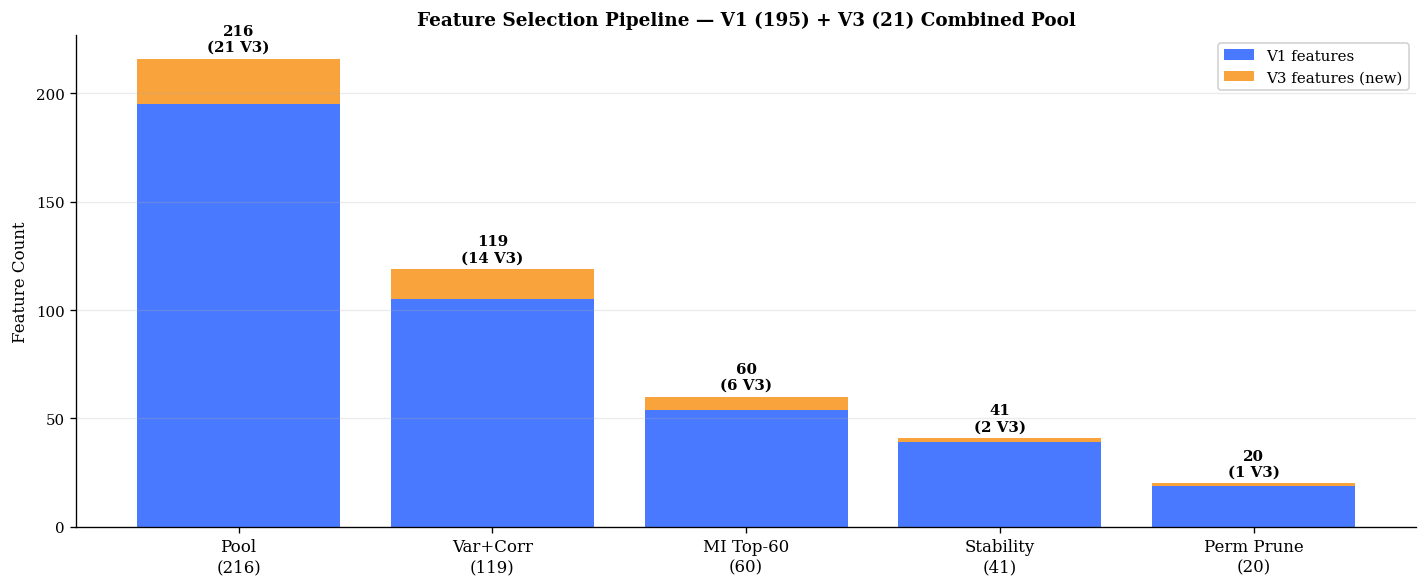

In [26]:
# ── Pipeline summary ──────────────────────────────────────────────────────────
print('FEATURE SELECTION PIPELINE SUMMARY')
print('─' * 55)
print(f'Stage 0 (Pool):      {len(ALL_FEATURE_COLS):>4}  ({len(V1_FEATURE_COLS)} V1 + {len(V3_FEATURE_COLS)} V3)')
print(f'Stage 1 (Filter):    {len(stage1):>4}  ({len(v3_in_s1)} V3)')
print(f'Stage 2 (MI Rank):   {len(stage2):>4}  ({n_v3_s2} V3)')
print(f'Stage 3 (Stability): {len(stage3):>4}  ({len(v3_in_s3)} V3)')
print(f'Stage 4 (Prune):     {len(SELECTED_FEATURES):>4}  ({len(v3_in_s4)} V3)')
print(f'\nFinal feature set ({len(SELECTED_FEATURES)} features):')
for i, f in enumerate(SELECTED_FEATURES):
    tag = '[V3]' if f in V3_FEATURE_COLS else '    '
    print(f'  {i+1:>2}. {tag} {f}')

# ── Funnel chart ──────────────────────────────────────────────────────────────
stage_labels = [
    f'Pool\n({len(ALL_FEATURE_COLS)})',
    f'Var+Corr\n({len(stage1)})',
    f'MI Top-60\n({len(stage2)})',
    f'Stability\n({len(stage3)})',
    f'Perm Prune\n({len(SELECTED_FEATURES)})',
]
counts    = [len(ALL_FEATURE_COLS), len(stage1), len(stage2), len(stage3), len(SELECTED_FEATURES)]
v3_counts = [len(V3_FEATURE_COLS),  len(v3_in_s1), n_v3_s2,  len(v3_in_s3), len(v3_in_s4)]
v1_counts = [c - v for c, v in zip(counts, v3_counts)]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(stage_labels))
ax.bar(x, v1_counts, color=BLUE,  alpha=0.85, label='V1 features')
ax.bar(x, v3_counts, bottom=v1_counts, color=ACCENT, alpha=0.85, label='V3 features (new)')
for xi, (c, v) in enumerate(zip(counts, v3_counts)):
    ax.text(xi, c + max(counts) * 0.01, f'{c}\n({v} V3)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(stage_labels, fontsize=10)
ax.set_ylabel('Feature Count')
ax.set_title(
    f'Feature Selection Pipeline — V1 ({len(V1_FEATURE_COLS)}) + V3 ({len(V3_FEATURE_COLS)}) Combined Pool',
    fontweight='bold',
)
ax.legend()
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(ARTS_DIR / '00_pipeline_funnel.png')
plt.show()

---
## Phase 2 — Walk-Forward Optimization (4 Schemes)

Each scheme trains a fresh LightGBM every 720 bars (1 month), predicts the next 720 bars OOS.  
**Embargo**: 12 bars between train end and test start (matches 6h label lookahead).  
**Early stopping**: last 20% of each train window is held out as validation.

OOS period: **2024-01-01 → end of data** (~28 monthly WFO windows).

In [27]:
print('=' * 65)
print('PHASE 2 — WALK-FORWARD OPTIMIZATION')
print('=' * 65)

WFO_SCHEMES = {
    'EXP': {'name': 'Expanding (All History)', 'train_bars': None,  'color': BLUE},
    'L2Y': {'name': '2-Year Sliding',          'train_bars': 17520, 'color': ACCENT},
    'M1Y': {'name': '1-Year Sliding',          'train_bars': 8760,  'color': GREEN},
    'S3M': {'name': '3-Month Sliding',         'train_bars': 2160,  'color': RED},
}

BASE_LGBM_PARAMS = dict(
    num_leaves=31, max_depth=6, learning_rate=0.05,
    colsample_bytree=0.7, min_child_samples=50, subsample=0.7,
    reg_alpha=0.1, reg_lambda=1.0, n_estimators=500,
)

oos_df = merged[oos_mask].copy()
print(f'OOS period : {oos_df.index.min().date()} → {oos_df.index.max().date()}')
print(f'OOS bars   : {len(oos_df):,}')
print(f'Features   : {len(SELECTED_FEATURES)}')
print(f'\nWFO schemes:')
for sk, sc in WFO_SCHEMES.items():
    tb = f'{sc["train_bars"]:,} bars' if sc['train_bars'] else 'all past data'
    print(f'  {sk}: {sc["name"]:<28}  train={tb}')

PHASE 2 — WALK-FORWARD OPTIMIZATION
OOS period : 2024-01-01 → 2026-05-16
OOS bars   : 20,785
Features   : 20

WFO schemes:
  EXP: Expanding (All History)       train=all past data
  L2Y: 2-Year Sliding                train=17,520 bars
  M1Y: 1-Year Sliding                train=8,760 bars
  S3M: 3-Month Sliding               train=2,160 bars


In [28]:
def run_wfo(
    scheme_key: str,
    lgbm_params: dict = None,
    verbose: bool = True,
) -> pd.Series:
    """Walk-forward optimization for one training-window scheme.

    Returns OOS probability series indexed by timestamp.
    """
    if lgbm_params is None:
        lgbm_params = BASE_LGBM_PARAMS
    scheme = WFO_SCHEMES[scheme_key]

    n_oos     = len(oos_df)
    probs_all = np.full(n_oos, np.nan)
    n_fits    = 0

    step = 0
    while step * STEP_SIZE < n_oos:
        t0_pos = step * STEP_SIZE
        t1_pos = min((step + 1) * STEP_SIZE, n_oos)

        # Absolute index in merged for the first test bar
        first_test_ts = oos_df.index[t0_pos]
        abs_test_start = merged.index.searchsorted(first_test_ts)

        train_end_abs = abs_test_start - EMBARGO
        if train_end_abs < 300:
            step += 1
            continue

        if scheme['train_bars'] is None:
            train_start_abs = 0
        else:
            train_start_abs = max(0, train_end_abs - scheme['train_bars'])

        train_slice = merged.iloc[train_start_abs:train_end_abs]
        if len(train_slice) < 300:
            step += 1
            continue

        val_n = max(100, int(len(train_slice) * VAL_FRAC))
        tr = train_slice.iloc[:-val_n]
        va = train_slice.iloc[-val_n:]

        if tr[LABEL_COL].nunique() < 2 or va[LABEL_COL].nunique() < 2:
            step += 1
            continue

        X_tr = tr[SELECTED_FEATURES].fillna(0).values
        y_tr = tr[LABEL_COL].values
        X_va = va[SELECTED_FEATURES].fillna(0).values
        y_va = va[LABEL_COL].values

        model = lgb.LGBMClassifier(
            **lgbm_params, verbose=-1, random_state=42, n_jobs=-1
        )
        model.fit(
            X_tr, y_tr, eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(30, verbose=False)],
        )

        X_test = oos_df.iloc[t0_pos:t1_pos][SELECTED_FEATURES].fillna(0).values
        probs  = model.predict_proba(X_test)[:, 1]
        probs_all[t0_pos:t1_pos] = probs
        n_fits += 1
        step   += 1

    if verbose:
        print(f'  [{scheme_key}] {scheme["name"]}: {n_fits} WFO fits')
    return pd.Series(probs_all, index=oos_df.index, name=scheme_key)

In [29]:
wfo_probs = {}
t_all = time.time()

for sk in WFO_SCHEMES:
    print(f'\n{"─"*60}')
    print(f'Running {sk}: {WFO_SCHEMES[sk]["name"]}')
    probs = run_wfo(sk)
    wfo_probs[sk] = probs

elapsed = time.time() - t_all
print(f'\nAll 4 WFO schemes done in {elapsed/60:.1f} min')


────────────────────────────────────────────────────────────
Running EXP: Expanding (All History)
  [EXP] Expanding (All History): 29 WFO fits

────────────────────────────────────────────────────────────
Running L2Y: 2-Year Sliding
  [L2Y] 2-Year Sliding: 29 WFO fits

────────────────────────────────────────────────────────────
Running M1Y: 1-Year Sliding
  [M1Y] 1-Year Sliding: 29 WFO fits

────────────────────────────────────────────────────────────
Running S3M: 3-Month Sliding
  [S3M] 3-Month Sliding: 29 WFO fits

All 4 WFO schemes done in 0.6 min


In [30]:
y_oos = oos_df[LABEL_COL].values


def _equity_from_probs(
    probs_arr,
    threshold=DEFAULT_THRESHOLD,
    entry_atr_mult=DEFAULT_ENTRY_ATR,
    sl_mult=DEFAULT_SL_MULT,
    tp_mult=DEFAULT_TP_MULT,
    max_hold=DEFAULT_MAX_HOLD,
    cooldown_bars=DEFAULT_COOLDOWN,
):
    """Long-only ATR-stop equity from probability array."""
    n         = len(oos_df)
    close_arr = oos_df['close'].values
    high_arr  = oos_df['high'].values
    low_arr   = oos_df['low'].values
    atr_arr   = oos_df['atr_14_pct'].values

    equity_arr = np.ones(n)
    cur_eq     = 1.0
    in_pos     = False
    pos_eq     = 1.0
    entry_px   = sl_px = tp_px = 0.0
    entry_bar  = hold_count = cooldown_count = 0
    pending    = None  # (limit_px, sl_px, tp_px)

    for i in range(n):
        if in_pos:
            hold_count += 1
            lo = low_arr[i]; hi = high_arr[i]
            equity_arr[i] = pos_eq * close_arr[i] / entry_px  # mark-to-market
            exited = False; exit_px = 0.0
            if lo <= sl_px:                           exit_px = sl_px;         exited = True
            elif hi >= tp_px:                          exit_px = tp_px;         exited = True
            elif hold_count >= max_hold:               exit_px = close_arr[i];  exited = True
            if exited:
                cur_eq = pos_eq * (exit_px / entry_px)
                equity_arr[i] = cur_eq
                in_pos = False; cooldown_count = cooldown_bars

        elif pending is not None:
            lim_px, p_sl, p_tp = pending
            entry_px = lim_px if low_arr[i] <= lim_px else close_arr[i]
            sl_px = p_sl; tp_px = p_tp
            in_pos = True; pos_eq = cur_eq; entry_bar = i; hold_count = 0; pending = None
            equity_arr[i] = cur_eq

        elif cooldown_count > 0:
            cooldown_count -= 1; equity_arr[i] = cur_eq

        elif not np.isnan(probs_arr[i]) and probs_arr[i] > threshold and i + 1 < n:
            atr = atr_arr[i]; px = close_arr[i]
            pending = (
                px * (1 - entry_atr_mult * atr),
                px * (1 - sl_mult * atr),
                px * (1 + tp_mult * atr),
            )
            equity_arr[i] = cur_eq

        else:
            equity_arr[i] = cur_eq

    if in_pos:
        cur_eq = pos_eq * (close_arr[-1] / entry_px)
        equity_arr[-1] = cur_eq
    return equity_arr


def _sharpe(eq):
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    return float(r.mean() / (r.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))

def _maxdd(eq):
    pk = np.maximum.accumulate(eq)
    return float(((eq - pk) / (pk + 1e-12)).min())


wfo_metrics = {}
print(f'{"Scheme":<6}  {"Name":<28}  {"AUC":>6}  {"Sharpe":>7}  {"Return":>8}  {"MaxDD":>7}  {"Signals":>8}')
print('─' * 80)

for sk, probs_s in wfo_probs.items():
    pa    = probs_s.values
    valid = ~np.isnan(pa)
    auc   = roc_auc_score(y_oos[valid], pa[valid]) if valid.sum() > 100 else 0.5
    eq    = _equity_from_probs(pa)
    sh    = _sharpe(eq)
    dd    = _maxdd(eq)
    ret   = eq[-1] - 1
    nsig  = int((pa[valid] > DEFAULT_THRESHOLD).sum())
    wfo_metrics[sk] = {'auc': auc, 'sharpe': sh, 'total_ret': ret,
                       'maxdd': dd, 'equity': eq, 'n_signals': nsig}
    print(f'{sk:<6}  {WFO_SCHEMES[sk]["name"]:<28}  {auc:.4f}  {sh:>7.3f}  '
          f'{ret:>+7.1%}  {dd:>7.1%}  {nsig:>8}')

# Buy & Hold baseline
bh_eq = oos_df['close'].values / oos_df['close'].iloc[0]
print(f'\nBuy & Hold: return={bh_eq[-1]-1:+.1%}  sharpe={_sharpe(bh_eq):.3f}  maxdd={_maxdd(bh_eq):.1%}')

BEST_SCHEME = max(wfo_metrics, key=lambda k: wfo_metrics[k]['auc'])
print(f'\n★ Best WFO scheme by OOS AUC: {BEST_SCHEME} ({WFO_SCHEMES[BEST_SCHEME]["name"]})')

Scheme  Name                             AUC   Sharpe    Return    MaxDD   Signals
────────────────────────────────────────────────────────────────────────────────
EXP     Expanding (All History)       0.5484    0.608   +52.5%   -23.4%      5297
L2Y     2-Year Sliding                0.5437    0.242   +17.6%   -24.0%      4243
M1Y     1-Year Sliding                0.5404    0.322   +21.6%   -26.0%      3406
S3M     3-Month Sliding               0.5273    1.151   +84.5%   -16.1%      2700

Buy & Hold: return=+86.3%  sharpe=0.542  maxdd=-50.1%

★ Best WFO scheme by OOS AUC: EXP (Expanding (All History))


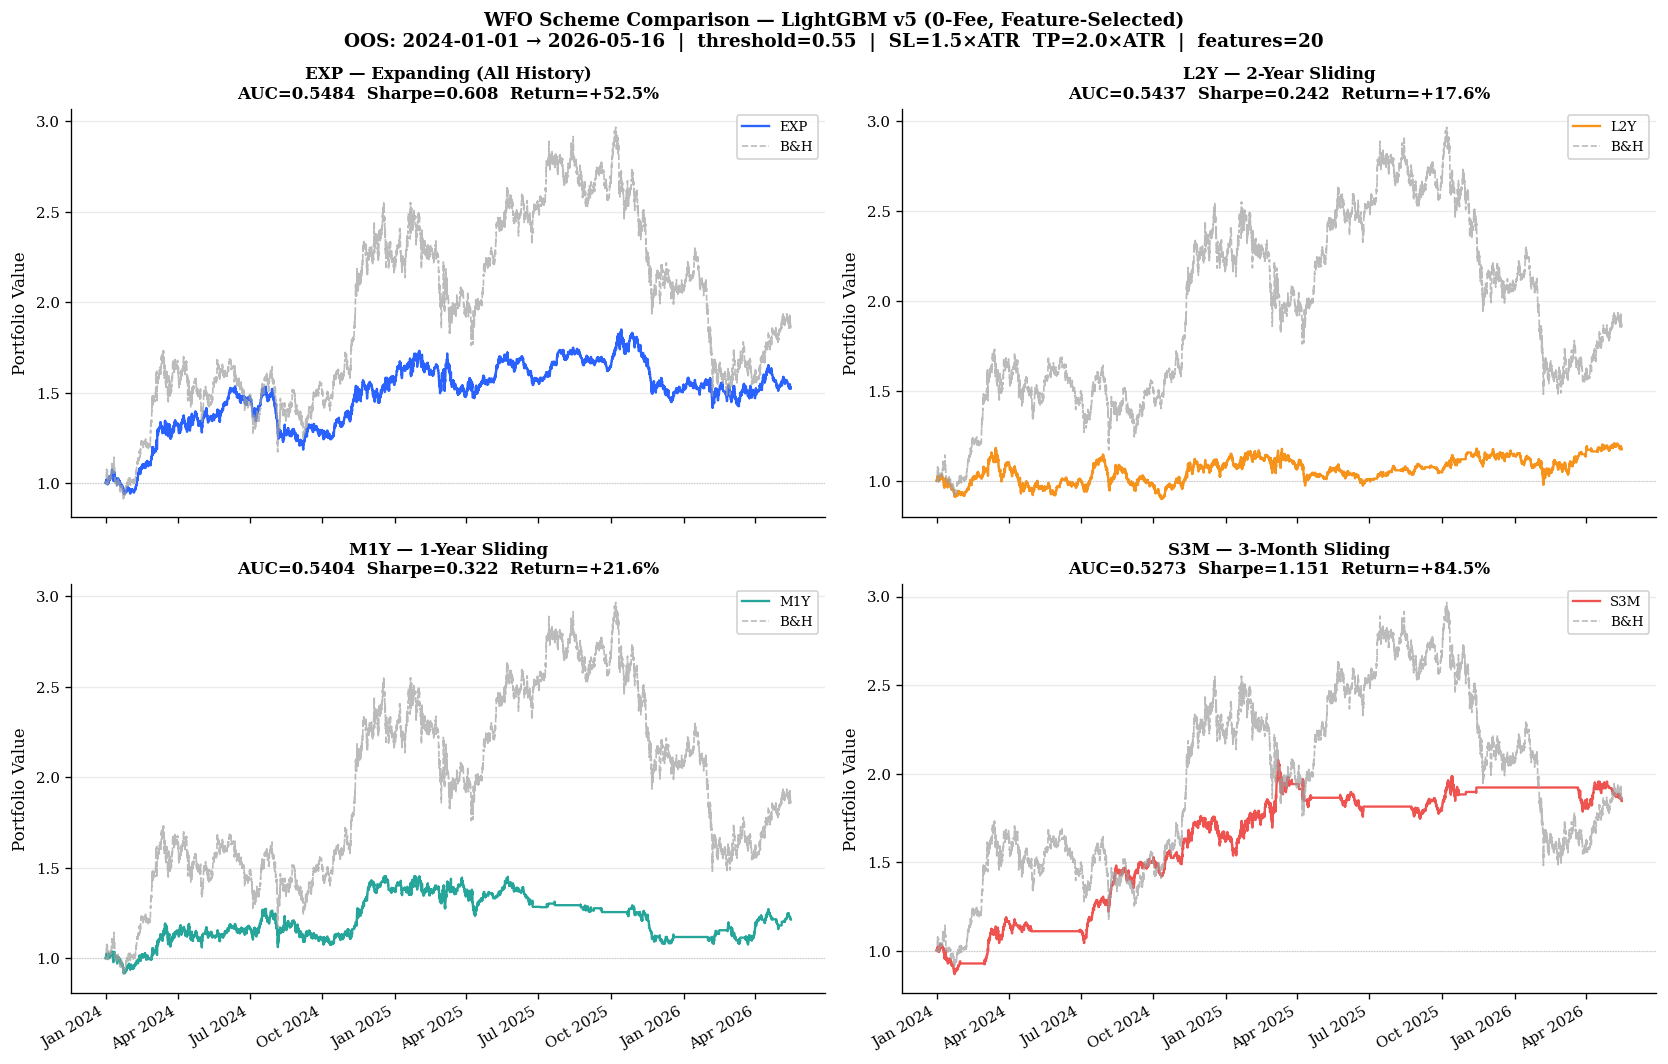

In [31]:
oos_index = oos_df.index

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()

for ax, (sk, scheme) in zip(axes, WFO_SCHEMES.items()):
    m  = wfo_metrics[sk]
    eq = m['equity']
    ax.plot(oos_index, eq,    color=scheme['color'], lw=1.4, label=sk)
    ax.plot(oos_index, bh_eq, color=GREY, lw=1.0, ls='--', alpha=0.7, label='B&H')
    ax.axhline(1.0, color=GREY, lw=0.6, ls=':', alpha=0.5)
    ax.set_title(
        f'{sk} — {scheme["name"]}\n'
        f'AUC={m["auc"]:.4f}  Sharpe={m["sharpe"]:.3f}  Return={m["total_ret"]:+.1%}',
        fontsize=10, fontweight='bold',
    )
    ax.set_ylabel('Portfolio Value')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.25)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle(
    f'WFO Scheme Comparison — LightGBM v5 (0-Fee, Feature-Selected)\n'
    f'OOS: {oos_df.index.min().date()} → {oos_df.index.max().date()}  '
    f'|  threshold={DEFAULT_THRESHOLD}  '
    f'|  SL={DEFAULT_SL_MULT}×ATR  TP={DEFAULT_TP_MULT}×ATR  '
    f'|  features={len(SELECTED_FEATURES)}',
    fontweight='bold', fontsize=11,
)
fig.tight_layout()
fig.savefig(ARTS_DIR / '01_wfo_scheme_comparison.png')
plt.show()

---
## Phase 3 — Parameter Grid Search

Search 16 parameter combinations on the **best WFO scheme** (highest OOS AUC from Phase 2).  
Grid: `num_leaves` × `max_depth` × `learning_rate` × `colsample_bytree` = 2×2×2×2 = 16 combos.

In [ ]:
print('=' * 65)
print(f'PHASE 3 — GRID SEARCH ON BEST SCHEME: {BEST_SCHEME}')
print('=' * 65)

PARAM_GRID = {
    'num_leaves':        [15, 31],
    'max_depth':         [6, 8],
    'learning_rate':     [0.03, 0.05],
    'colsample_bytree':  [0.5, 0.7],
    'min_child_samples': [50],
    'subsample':         [0.7],
    'reg_alpha':         [0.1],
    'reg_lambda':        [1.0],
    'n_estimators':      [500],
}

keys   = list(PARAM_GRID.keys())
combos = list(itertools.product(*[PARAM_GRID[k] for k in keys]))
print(f'Grid combinations: {len(combos)}')

grid_results = []
t_grid = time.time()

for i, vals in enumerate(combos):
    params = dict(zip(keys, vals))
    if (i + 1) % 4 == 1:
        print(f'  Combo {i+1:>2}/{len(combos)}  ...  ({time.time()-t_grid:.0f}s elapsed)')

    probs_s  = run_wfo(BEST_SCHEME, lgbm_params=params, verbose=False)
    pa       = probs_s.values
    valid    = ~np.isnan(pa)
    if valid.sum() < 100:
        continue

    auc    = roc_auc_score(y_oos[valid], pa[valid])
    eq     = _equity_from_probs(pa)
    n_sig  = int((pa[valid] > DEFAULT_THRESHOLD).sum())
    grid_results.append({
        **params,
        'auc':       auc,
        'sharpe':    _sharpe(eq),
        'total_ret': eq[-1] - 1,
        'maxdd':     _maxdd(eq),
        'n_trades':  n_sig,
    })

grid_df = pd.DataFrame(grid_results).sort_values('auc', ascending=False).reset_index(drop=True)
print(f'\nGrid search done in {(time.time()-t_grid)/60:.1f} min')
print(f'\nTop 10 by OOS AUC:')
disp = ['num_leaves','max_depth','learning_rate','colsample_bytree','auc','sharpe','total_ret','n_trades']
print(grid_df[[c for c in disp if c in grid_df.columns]].head(10).to_string(index=False))

# Cast integer params back from DataFrame floats → ints before passing to LightGBM
_INT_KEYS = {'num_leaves', 'max_depth', 'min_child_samples', 'n_estimators'}
BEST_PARAMS = {
    k: int(grid_df.iloc[0][k]) if k in _INT_KEYS else float(grid_df.iloc[0][k])
    for k in keys
}
print(f'\n★ Best params: {BEST_PARAMS}')
print(f'  OOS AUC    : {grid_df.iloc[0]["auc"]:.4f}')
print(f'  OOS Sharpe : {grid_df.iloc[0]["sharpe"]:.3f}')
print(f'  OOS Return : {grid_df.iloc[0]["total_ret"]:+.2%}')

PHASE 3 — GRID SEARCH ON BEST SCHEME: EXP
Grid combinations: 16
  Combo  1/16  ...  (0s elapsed)
  Combo  5/16  ...  (66s elapsed)
  Combo  9/16  ...  (137s elapsed)


In [ ]:
pivot_auc    = grid_df.pivot_table(index='num_leaves', columns='learning_rate',
                                   values='auc',    aggfunc='max')
pivot_sharpe = grid_df.pivot_table(index='num_leaves', columns='learning_rate',
                                   values='sharpe', aggfunc='max')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(pivot_auc,    ax=axes[0], annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'OOS AUC'})
axes[0].set_title(
    f'Grid Search: OOS AUC\n'
    f'(num_leaves × learning_rate | best of depth & colsample)',
    fontweight='bold',
)
axes[0].set_xlabel('learning_rate'); axes[0].set_ylabel('num_leaves')

sns.heatmap(pivot_sharpe, ax=axes[1], annot=True, fmt='.3f', cmap='YlGn',
            linewidths=0.5, cbar_kws={'label': 'Annualized Sharpe'})
axes[1].set_title(
    f'Grid Search: Annualized Sharpe\n'
    f'(num_leaves × learning_rate | best of depth & colsample)',
    fontweight='bold',
)
axes[1].set_xlabel('learning_rate'); axes[1].set_ylabel('num_leaves')

fig.suptitle(
    f'LightGBM Grid Search — {WFO_SCHEMES[BEST_SCHEME]["name"]} WFO  |  {len(SELECTED_FEATURES)} features',
    fontweight='bold',
)
fig.tight_layout()
fig.savefig(ARTS_DIR / '02_grid_search_heatmap.png')
plt.show()

---
## Phase 4 — Backtesting with Best Params

Long-only ATR-based limit-entry / SL / TP backtester (0 fees):

- **Entry**: P(up) > threshold → limit order at `close × (1 − entry_atr × atr_14_pct)`; if unfilled next bar, market fill
- **Stop loss**: `close × (1 − sl_mult × atr_14_pct)`
- **Take profit**: `close × (1 + tp_mult × atr_14_pct)`
- **Max hold**: 48 bars (2 days)
- **Cooldown**: 4 bars between signals

In [ ]:
print('=' * 65)
print('PHASE 4 — BACKTESTING WITH BEST PARAMS')
print('=' * 65)

# Re-run WFO with best params
print(f'Re-running WFO ({BEST_SCHEME}) with best params...')
best_probs_s = run_wfo(BEST_SCHEME, lgbm_params=BEST_PARAMS)


def run_full_backtest(
    df_oos: pd.DataFrame,
    probs_series: pd.Series,
    threshold: float = DEFAULT_THRESHOLD,
    entry_atr_mult: float = DEFAULT_ENTRY_ATR,
    sl_mult: float = DEFAULT_SL_MULT,
    tp_mult: float = DEFAULT_TP_MULT,
    max_hold: int = DEFAULT_MAX_HOLD,
    cooldown_bars: int = DEFAULT_COOLDOWN,
):
    """Full long-only ATR-stop backtester with trade log."""
    n         = len(df_oos)
    close_arr = df_oos['close'].values
    high_arr  = df_oos['high'].values
    low_arr   = df_oos['low'].values
    atr_arr   = df_oos['atr_14_pct'].values
    probs     = probs_series.reindex(df_oos.index).fillna(0).values

    equity_arr = np.ones(n)
    cur_eq     = 1.0
    trade_log  = []

    in_pos       = False
    pos_eq       = 1.0
    entry_px     = sl_px = tp_px = 0.0
    entry_bar    = hold_count = cooldown_count = 0
    pending      = None  # (limit_px, sl_px, tp_px)

    for i in range(n):
        if in_pos:
            hold_count += 1
            lo = low_arr[i]; hi = high_arr[i]
            equity_arr[i] = pos_eq * close_arr[i] / entry_px  # mark-to-market
            exited = False; exit_px = 0.0; reason = ''
            if   lo <= sl_px:            exit_px = sl_px;        exited = True; reason = 'sl'
            elif hi >= tp_px:            exit_px = tp_px;        exited = True; reason = 'tp'
            elif hold_count >= max_hold: exit_px = close_arr[i]; exited = True; reason = 'timeout'
            if exited:
                cur_eq = pos_eq * (exit_px / entry_px)
                equity_arr[i] = cur_eq
                trade_log.append({
                    'entry_bar':  entry_bar,
                    'exit_bar':   i,
                    'entry_time': df_oos.index[entry_bar],
                    'exit_time':  df_oos.index[i],
                    'entry_px':   float(entry_px),
                    'exit_px':    float(exit_px),
                    'pnl_pct':    float((exit_px / entry_px - 1) * 100),
                    'reason':     reason,
                    'hold_bars':  hold_count,
                })
                in_pos = False; cooldown_count = cooldown_bars

        elif pending is not None:
            lim_px, p_sl, p_tp = pending
            entry_px = lim_px if low_arr[i] <= lim_px else close_arr[i]
            sl_px = p_sl; tp_px = p_tp
            in_pos = True; pos_eq = cur_eq; entry_bar = i; hold_count = 0; pending = None
            equity_arr[i] = cur_eq

        elif cooldown_count > 0:
            cooldown_count -= 1; equity_arr[i] = cur_eq

        elif not np.isnan(probs[i]) and probs[i] > threshold and i + 1 < n:
            atr = atr_arr[i]; px = close_arr[i]
            pending = (
                px * (1.0 - entry_atr_mult * atr),
                px * (1.0 - sl_mult        * atr),
                px * (1.0 + tp_mult        * atr),
            )
            equity_arr[i] = cur_eq
        else:
            equity_arr[i] = cur_eq

    if in_pos:
        cur_eq = pos_eq * (close_arr[-1] / entry_px)
        equity_arr[-1] = cur_eq
        trade_log.append({
            'entry_bar': entry_bar, 'exit_bar': n - 1,
            'entry_time': df_oos.index[entry_bar], 'exit_time': df_oos.index[-1],
            'entry_px': float(entry_px), 'exit_px': float(close_arr[-1]),
            'pnl_pct': float((close_arr[-1] / entry_px - 1) * 100),
            'reason': 'eod', 'hold_bars': hold_count,
        })

    return equity_arr, pd.DataFrame(trade_log)


# Run at two thresholds
eq_055, tdf_055 = run_full_backtest(oos_df, best_probs_s, threshold=0.55)
eq_060, tdf_060 = run_full_backtest(oos_df, best_probs_s, threshold=0.60)

for thr, eq, tdf in [(0.55, eq_055, tdf_055), (0.60, eq_060, tdf_060)]:
    wr = (tdf['pnl_pct'] > 0).mean() if len(tdf) > 0 else 0.0
    by_r = dict(tdf['reason'].value_counts()) if len(tdf) > 0 else {}
    print(f'\nThreshold {thr:.2f}:')
    print(f'  Trades    : {len(tdf)}')
    print(f'  Win rate  : {wr:.1%}')
    print(f'  Total ret : {eq[-1]-1:+.2%}')
    print(f'  Sharpe    : {_sharpe(eq):.3f}')
    print(f'  Max DD    : {_maxdd(eq):.2%}')
    print(f'  By reason : {by_r}')

---
## Phase 5 — Visualizations

In [ ]:
# ── Chart 1: Equity + Drawdown overlay with trade markers ─────────────────────
print('=' * 65)
print('PHASE 5 — VISUALIZATIONS')
print('=' * 65)

eq  = eq_055
tdf = tdf_055.copy() if len(tdf_055) > 0 else pd.DataFrame()

fig, axes = plt.subplots(
    2, 1, figsize=(14, 9),
    gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08},
)

ax = axes[0]
ax.plot(oos_index, eq,    color=ACCENT, lw=1.5, label=f'LGBM v5 (0-fee, p>{DEFAULT_THRESHOLD})')
ax.plot(oos_index, bh_eq, color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':', alpha=0.6)

if len(tdf) > 0:
    for _, row in tdf.iterrows():
        ib = int(row['entry_bar']); ob = int(row['exit_bar'])
        if ib < len(oos_index):
            ax.plot(oos_index[ib], eq[ib], marker='^', color=GREEN,
                    ms=5, alpha=0.70, zorder=5, linestyle='None')
        if ob < len(oos_index):
            ax.plot(oos_index[ob], eq[ob], marker='v', color=RED,
                    ms=5, alpha=0.70, zorder=5, linestyle='None')

entry_patch = mpatches.Patch(facecolor=GREEN, label='▲ Entry')
exit_patch  = mpatches.Patch(facecolor=RED,   label='▼ Exit')
ax.legend(
    handles=[ax.lines[0], ax.lines[1], entry_patch, exit_patch],
    ncol=2,
)
win_rate = (tdf['pnl_pct'] > 0).mean() if len(tdf) > 0 else 0
ax.set_ylabel('Portfolio Value')
ax.set_title(
    f'LGBM v5 — Feature-Selected WFO Equity (OOS, 0-Fee)\n'
    f'Scheme: {WFO_SCHEMES[BEST_SCHEME]["name"]}  |  {len(tdf)} trades  |  '
    f'Return: {eq[-1]-1:+.2%}  Sharpe: {_sharpe(eq):.3f}  MaxDD: {_maxdd(eq):.2%}',
    fontweight='bold',
)
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

ax2 = axes[1]
pk_s = np.maximum.accumulate(eq)
pk_b = np.maximum.accumulate(bh_eq)
ax2.fill_between(oos_index, (eq    - pk_s) / (pk_s + 1e-12) * 100, 0,
                 color=ACCENT, alpha=0.45, label='LGBM v5')
ax2.fill_between(oos_index, (bh_eq - pk_b) / (pk_b + 1e-12) * 100, 0,
                 color=BLUE,  alpha=0.25, label='B&H')
ax2.set_ylabel('Drawdown (%)')
ax2.legend(ncol=2)
ax2.grid(axis='y', alpha=0.3); ax2.grid(axis='x', alpha=0.15)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.text(
    0.5, 0.005,
    f'scheme={BEST_SCHEME}  features={len(SELECTED_FEATURES)}  '
    f'threshold={DEFAULT_THRESHOLD}  entry={DEFAULT_ENTRY_ATR}×ATR  '
    f'SL={DEFAULT_SL_MULT}×ATR  TP={DEFAULT_TP_MULT}×ATR  '
    f'max_hold={DEFAULT_MAX_HOLD}h  cooldown={DEFAULT_COOLDOWN}  '
    f'trades={len(tdf)}  win_rate={win_rate:.1%}',
    ha='center', va='bottom', fontsize=8, color=GREY,
)
fig.tight_layout(rect=[0, 0.02, 1, 1])
fig.savefig(ARTS_DIR / '03_equity_drawdown.png')
plt.show()

In [ ]:
# ── Chart 2: Probability distributions — class 0 vs class 1 ──────────────────
pa    = best_probs_s.values
valid = ~np.isnan(pa)
n_oos_bars = len(y_oos)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

half = n_oos_bars // 2
splits = [
    ('Full OOS Period', valid),
    ('Second Half OOS', np.concatenate([np.zeros(half, bool), np.ones(n_oos_bars - half, bool)]) & valid),
]

for ax, (title, mask) in zip(axes, splits):
    y_sub = y_oos[mask]
    p_sub = pa[mask]
    if len(p_sub) < 10 or len(np.unique(y_sub)) < 2:
        ax.set_title(f'{title}\n(insufficient data)')
        continue
    auc_sub = roc_auc_score(y_sub, p_sub)
    ax.hist(p_sub[y_sub == 0], bins=40, alpha=0.60, label='Down (label=0)',
            color=RED, density=True)
    ax.hist(p_sub[y_sub == 1], bins=40, alpha=0.60, label='Up (label=1)',
            color=GREEN, density=True)
    ax.axvline(DEFAULT_THRESHOLD, color=GREY, lw=1.2, ls='--',
               label=f'Threshold {DEFAULT_THRESHOLD}')
    ax.set_title(f'{title}\nAUC = {auc_sub:.4f}', fontweight='bold')
    ax.set_xlabel('P(Up)'); ax.set_ylabel('Density'); ax.legend()

fig.suptitle(
    f'OOS Probability Distributions — LGBM v5 Feature-Selected WFO\n'
    f'({WFO_SCHEMES[BEST_SCHEME]["name"]}  |  {len(SELECTED_FEATURES)} features)',
    fontweight='bold',
)
fig.tight_layout()
fig.savefig(ARTS_DIR / '04_probability_distributions.png')
plt.show()

In [ ]:
# ── Chart 3: Feature importance — train final model on all pre-OOS data ───────
print('Training final model for feature importance...')
train_full   = merged[~oos_mask]
val_n_final  = max(500, int(len(train_full) * 0.15))
X_tr_f = train_full.iloc[:-val_n_final][SELECTED_FEATURES].fillna(0).values
y_tr_f = train_full.iloc[:-val_n_final][LABEL_COL].values
X_va_f = train_full.iloc[-val_n_final:][SELECTED_FEATURES].fillna(0).values
y_va_f = train_full.iloc[-val_n_final:][LABEL_COL].values

final_model = lgb.LGBMClassifier(
    **{k: BEST_PARAMS[k] for k in keys},
    verbose=-1, random_state=42, n_jobs=-1,
)
final_model.fit(
    X_tr_f, y_tr_f, eval_set=[(X_va_f, y_va_f)],
    callbacks=[lgb.early_stopping(30, verbose=False)],
)
print(f'  Best iteration: {final_model.best_iteration_}')

lgb_imp = pd.DataFrame({
    'feature': SELECTED_FEATURES,
    'gain':    final_model.feature_importances_,
    'is_v3':   [f in V3_FEATURE_COLS for f in SELECTED_FEATURES],
}).sort_values('gain', ascending=False).reset_index(drop=True)

colors = [ACCENT if v3 else BLUE for v3 in lgb_imp['is_v3']]
fig, ax = plt.subplots(figsize=(10, max(5, len(lgb_imp) * 0.38)))
ax.barh(range(len(lgb_imp)), lgb_imp['gain'].values, color=colors, alpha=0.85)
ax.set_yticks(range(len(lgb_imp)))
ax.set_yticklabels(lgb_imp['feature'].values, fontsize=9)
ax.set_xlabel('LightGBM Gain Importance')
ax.set_title(
    f'Feature Importance — Final Model ({len(SELECTED_FEATURES)} features)\n'
    f'(blue = V1 OHLCV-based, orange = V3 external data)',
    fontweight='bold',
)
ax.invert_yaxis()
ax.legend(handles=[
    mpatches.Patch(facecolor=BLUE,  label=f'V1 features ({len(V1_FEATURE_COLS)} pool)'),
    mpatches.Patch(facecolor=ACCENT, label=f'V3 features ({len(V3_FEATURE_COLS)} new)'),
])
fig.tight_layout()
fig.savefig(ARTS_DIR / '05_feature_importance.png')
plt.show()

In [ ]:
# ── Chart 4: Trade-level scatter ──────────────────────────────────────────────
if len(tdf_055) > 0:
    wins  = tdf_055[tdf_055['pnl_pct'] >  0]
    loses = tdf_055[tdf_055['pnl_pct'] <= 0]

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.scatter(wins['entry_time'],  wins['pnl_pct'],
               color=GREEN, alpha=0.70, s=30, label='Win', zorder=3)
    ax.scatter(loses['entry_time'], loses['pnl_pct'],
               color=RED,   alpha=0.70, s=30, label='Loss', zorder=3)
    ax.axhline(0, color=GREY, lw=0.8, ls='--')
    wr = (tdf_055['pnl_pct'] > 0).mean()
    avg_win  = wins['pnl_pct'].mean()  if len(wins)  > 0 else 0.0
    avg_loss = loses['pnl_pct'].mean() if len(loses) > 0 else 0.0
    ax.set_xlabel('Entry Time'); ax.set_ylabel('PnL (%)')
    ax.set_title(
        f'Trade-Level Scatter — threshold=0.55\n'
        f'{len(tdf_055)} trades  |  Win rate: {wr:.1%}  '
        f'|  Avg win: {avg_win:+.2f}%  |  Avg loss: {avg_loss:+.2f}%  '
        f'|  Profit factor: {-wins["pnl_pct"].sum()/loses["pnl_pct"].sum():.2f}',
        fontweight='bold',
    )
    ax.legend()
    ax.grid(alpha=0.25)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    fig.tight_layout()
    fig.savefig(ARTS_DIR / '06_trade_scatter.png')
    plt.show()
else:
    print('No trades at threshold 0.55 — skipping scatter chart')

In [ ]:
# ── Chart 5: OOS probability time series with actual label shading ────────────
pa    = best_probs_s.values
valid = ~np.isnan(pa)

fig, ax = plt.subplots(figsize=(14, 4))

# Shade background by actual label (green = actual Up)
chunk = 24  # shade in 24-bar chunks for speed
for i in range(0, len(oos_index) - chunk, chunk):
    if y_oos[i] == 1:
        ax.axvspan(oos_index[i], oos_index[min(i + chunk, len(oos_index) - 1)],
                   alpha=0.06, color=GREEN, linewidth=0)

ax.plot(oos_index[valid], pa[valid], color=ACCENT, lw=0.6, alpha=0.85, label='P(Up)')
ax.axhline(DEFAULT_THRESHOLD, color=RED,  lw=1.2, ls='--',
           label=f'Threshold {DEFAULT_THRESHOLD}')
ax.axhline(0.5, color=GREY, lw=0.8, ls=':', alpha=0.6)

ax.set_ylabel('P(Up)'); ax.set_ylim(0, 1)
ax.set_title(
    f'OOS Probability Time Series — {WFO_SCHEMES[BEST_SCHEME]["name"]}\n'
    f'(green shading = actual Up bars  |  orange line = model P(Up))',
    fontweight='bold',
)
ax.legend()
ax.grid(alpha=0.25)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
fig.tight_layout()
fig.savefig(ARTS_DIR / '07_oos_probability_timeseries.png')
plt.show()

---
## Phase 6 — Fee Impact Analysis

Binance-style fee model applied to the best-params backtest:

| Route | Entry fee | Exit fee | Round-trip |
|-------|-----------|----------|------------|
| Spot long (limit entry, limit TP) | 0% maker FREE | 0% maker FREE | **0.00%** |
| Spot long (limit entry, SL/timeout) | 0% maker FREE | 0.05% taker | **0.05%** |
| Spot long (market entry, SL/timeout) | 0.05% taker | 0.05% taker | **0.10%** |

**Limit fill logic**: if `low[i] <= limit_price` on next bar → maker fee (FREE); otherwise market fill → taker fee.  
**TP exit**: limit order → maker fee (FREE).  
**SL / timeout exit**: market order → 0.05% taker fee.


In [ ]:
def run_backtest_with_fees(
    df_oos: pd.DataFrame,
    probs_series: pd.Series,
    threshold: float = DEFAULT_THRESHOLD,
    entry_atr_mult: float = DEFAULT_ENTRY_ATR,
    sl_mult: float = DEFAULT_SL_MULT,
    tp_mult: float = DEFAULT_TP_MULT,
    max_hold: int = DEFAULT_MAX_HOLD,
    cooldown_bars: int = DEFAULT_COOLDOWN,
    maker_fee: float = MAKER_FEE,
    taker_fee: float = SPOT_TAKER_FEE,
):
    """Long-only ATR-stop backtester with realistic Binance-style fees.

    Fee logic:
      - Entry limit filled on next bar's low  → maker_fee
      - Entry market fill (limit missed)       → taker_fee
      - TP exit (limit order)                  → maker_fee
      - SL / timeout exit (market order)       → taker_fee
    """
    n         = len(df_oos)
    close_arr = df_oos['close'].values
    high_arr  = df_oos['high'].values
    low_arr   = df_oos['low'].values
    atr_arr   = df_oos['atr_14_pct'].values
    probs     = probs_series.reindex(df_oos.index).fillna(0).values

    equity_arr     = np.ones(n)
    cur_eq         = 1.0
    trade_log      = []

    in_pos         = False
    pos_eq         = 1.0
    entry_px       = sl_px = tp_px = 0.0
    entry_bar      = hold_count = cooldown_count = 0
    entry_fee_paid = 0.0
    pending        = None  # (limit_px, sl_px, tp_px)

    for i in range(n):
        if in_pos:
            hold_count += 1
            lo = low_arr[i]; hi = high_arr[i]
            equity_arr[i] = pos_eq * close_arr[i] / entry_px   # mark-to-market (gross)
            exited = False; exit_px = 0.0; reason = ''; exit_fee = 0.0

            if   lo <= sl_px:            exit_px = sl_px;        exited = True; reason = 'sl';      exit_fee = taker_fee
            elif hi >= tp_px:            exit_px = tp_px;        exited = True; reason = 'tp';      exit_fee = maker_fee
            elif hold_count >= max_hold: exit_px = close_arr[i]; exited = True; reason = 'timeout'; exit_fee = taker_fee

            if exited:
                gross_ret = exit_px / entry_px - 1
                net_ret   = gross_ret - entry_fee_paid - exit_fee
                cur_eq    = pos_eq * (1.0 + net_ret)
                equity_arr[i] = cur_eq
                trade_log.append({
                    'entry_bar':  entry_bar,  'exit_bar':  i,
                    'entry_time': df_oos.index[entry_bar],
                    'exit_time':  df_oos.index[i],
                    'entry_px':   float(entry_px),   'exit_px':  float(exit_px),
                    'gross_pct':  float(gross_ret * 100),
                    'pnl_pct':    float(net_ret   * 100),
                    'entry_fee':  float(entry_fee_paid), 'exit_fee': float(exit_fee),
                    'reason':     reason,    'hold_bars': hold_count,
                })
                in_pos = False; cooldown_count = cooldown_bars

        elif pending is not None:
            lim_px, p_sl, p_tp = pending
            if low_arr[i] <= lim_px:
                entry_px = lim_px;        entry_fee_paid = maker_fee   # limit filled
            else:
                entry_px = close_arr[i];  entry_fee_paid = taker_fee   # market fill
            sl_px = p_sl; tp_px = p_tp
            in_pos = True; pos_eq = cur_eq; entry_bar = i; hold_count = 0; pending = None
            equity_arr[i] = cur_eq

        elif cooldown_count > 0:
            cooldown_count -= 1; equity_arr[i] = cur_eq

        elif not np.isnan(probs[i]) and probs[i] > threshold and i + 1 < n:
            atr = atr_arr[i]; px = close_arr[i]
            pending = (
                px * (1.0 - entry_atr_mult * atr),
                px * (1.0 - sl_mult        * atr),
                px * (1.0 + tp_mult        * atr),
            )
            equity_arr[i] = cur_eq
        else:
            equity_arr[i] = cur_eq

    if in_pos:
        gross_ret = close_arr[-1] / entry_px - 1
        net_ret   = gross_ret - entry_fee_paid - taker_fee
        cur_eq    = pos_eq * (1.0 + net_ret)
        equity_arr[-1] = cur_eq
        trade_log.append({
            'entry_bar': entry_bar, 'exit_bar': n - 1,
            'entry_time': df_oos.index[entry_bar], 'exit_time': df_oos.index[-1],
            'entry_px': float(entry_px), 'exit_px': float(close_arr[-1]),
            'gross_pct': float(gross_ret * 100), 'pnl_pct': float(net_ret * 100),
            'entry_fee': float(entry_fee_paid), 'exit_fee': float(taker_fee),
            'reason': 'eod', 'hold_bars': hold_count,
        })

    return equity_arr, pd.DataFrame(trade_log)


# Run fee-aware backtests at both thresholds
eq_fee_055, tdf_fee_055 = run_backtest_with_fees(oos_df, best_probs_s, threshold=0.55)
eq_fee_060, tdf_fee_060 = run_backtest_with_fees(oos_df, best_probs_s, threshold=0.60)

print('Fee-aware backtest results:')
print(f'{"":12}  {"Trades":>7}  {"WinRate":>8}  {"Return":>8}  {"Sharpe":>7}  {"MaxDD":>7}')
print('─' * 60)
for lbl, eq, tdf in [
    ('0-fee  0.55', eq_055,     tdf_055),
    ('0-fee  0.60', eq_060,     tdf_060),
    ('w/fees 0.55', eq_fee_055, tdf_fee_055),
    ('w/fees 0.60', eq_fee_060, tdf_fee_060),
]:
    wr = (tdf['pnl_pct'] > 0).mean() if len(tdf) > 0 else 0.0
    print(f'{lbl:12}  {len(tdf):>7}  {wr:>8.1%}  '
          f'{eq[-1]-1:>+7.1%}  {_sharpe(eq):>7.3f}  {_maxdd(eq):>7.2%}')

if len(tdf_fee_055) > 0:
    avg_fee_drag = (tdf_fee_055['entry_fee'] + tdf_fee_055['exit_fee']).mean()
    avg_gross    = tdf_fee_055['gross_pct'].mean()
    avg_net      = tdf_fee_055['pnl_pct'].mean()
    print(f'\nFee drag analysis (threshold=0.55):'
          f'\n  Avg gross PnL/trade : {avg_gross:+.4f}%'
          f'\n  Avg round-trip fee  : {avg_fee_drag*100:.4f}%'
          f'\n  Avg net PnL/trade   : {avg_net:+.4f}%'
          f'\n  Break-even requires : gross > {avg_fee_drag*100:.4f}% per trade')

In [ ]:
# ── Chart: 0-fee vs fee-adjusted equity overlay (2×2: thr 0.55 / 0.60) ───────
fig, axes = plt.subplots(2, 2, figsize=(14, 9),
                         gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08})

for col_idx, (thr, eq_0fee, eq_fee, tdf_0fee, tdf_fee) in enumerate([
    (0.55, eq_055,     eq_fee_055, tdf_055,     tdf_fee_055),
    (0.60, eq_060,     eq_fee_060, tdf_060,     tdf_fee_060),
]):
    ax_eq = axes[0][col_idx]
    ax_dd = axes[1][col_idx]

    ax_eq.plot(oos_index, eq_0fee, color=ACCENT, lw=1.4, label=f'0-fee  (p>{thr})')
    ax_eq.plot(oos_index, eq_fee,  color=RED,    lw=1.4, label=f'w/fees (p>{thr})')
    ax_eq.plot(oos_index, bh_eq,   color=GREY,   lw=1.0, ls='--', alpha=0.7, label='B&H')
    ax_eq.axhline(1.0, color=GREY, lw=0.6, ls=':', alpha=0.5)

    n0 = len(tdf_0fee); nf = len(tdf_fee)
    wr_fee = (tdf_fee['pnl_pct'] > 0).mean() if nf > 0 else 0.0
    ax_eq.set_title(
        f'Threshold p > {thr}  |  {nf} trades  |  Win: {wr_fee:.1%}\n'
        f'0-fee: {eq_0fee[-1]-1:+.2%}  →  w/fees: {eq_fee[-1]-1:+.2%}  '
        f'(drag {eq_0fee[-1]-eq_fee[-1]:+.2%})',
        fontsize=10, fontweight='bold',
    )
    ax_eq.set_ylabel('Portfolio Value')
    ax_eq.legend(fontsize=8)
    ax_eq.grid(axis='y', alpha=0.25)

    pk_0 = np.maximum.accumulate(eq_0fee)
    pk_f = np.maximum.accumulate(eq_fee)
    pk_b = np.maximum.accumulate(bh_eq)
    ax_dd.fill_between(oos_index, (eq_0fee - pk_0) / (pk_0 + 1e-12) * 100, 0,
                       color=ACCENT, alpha=0.45, label='0-fee')
    ax_dd.fill_between(oos_index, (eq_fee  - pk_f) / (pk_f + 1e-12) * 100, 0,
                       color=RED,   alpha=0.35, label='w/fees')
    ax_dd.fill_between(oos_index, (bh_eq   - pk_b) / (pk_b + 1e-12) * 100, 0,
                       color=GREY,  alpha=0.20, label='B&H')
    ax_dd.set_ylabel('Drawdown (%)')
    ax_dd.legend(fontsize=8, ncol=3)
    ax_dd.grid(axis='y', alpha=0.25)

    for ax in [ax_eq, ax_dd]:
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle(
    f'Fee Impact: 0-Fee vs Binance Spot Fees (maker={MAKER_FEE*100:.2f}% / taker={SPOT_TAKER_FEE*100:.2f}%)\n'
    f'LGBM v5 — {WFO_SCHEMES[BEST_SCHEME]["name"]}  |  '
    f'SL={DEFAULT_SL_MULT}×ATR  TP={DEFAULT_TP_MULT}×ATR  entry={DEFAULT_ENTRY_ATR}×ATR',
    fontweight='bold', fontsize=11,
)
fig.tight_layout()
fig.savefig(ARTS_DIR / '08_fee_comparison.png')
plt.show()

In [ ]:
# ── Chart: threshold sweep — 0-fee vs fee-adjusted metrics ───────────────────
thresholds   = [0.52, 0.54, 0.55, 0.56, 0.58, 0.60, 0.62, 0.65]
sweep_rows   = []

for thr in thresholds:
    eq0, td0 = run_full_backtest(oos_df, best_probs_s, threshold=thr)
    eqf, tdf_ = run_backtest_with_fees(oos_df, best_probs_s, threshold=thr)
    wr0 = (td0['pnl_pct'] > 0).mean()  if len(td0) > 0 else 0.0
    wrf = (tdf_['pnl_pct'] > 0).mean() if len(tdf_) > 0 else 0.0
    sweep_rows.append({
        'threshold':    thr,
        'n_trades_0':   len(td0),
        'return_0fee':  eq0[-1] - 1,
        'sharpe_0fee':  _sharpe(eq0),
        'winrate_0fee': wr0,
        'return_fee':   eqf[-1] - 1,
        'sharpe_fee':   _sharpe(eqf),
        'winrate_fee':  wrf,
        'n_trades_fee': len(tdf_),
    })

sweep_df = pd.DataFrame(sweep_rows)
print('Threshold sweep — 0-fee vs w/fees:')
print(sweep_df.to_string(index=False))

# Plot sweep metrics
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

ax = axes[0]
ax.plot(sweep_df['threshold'], sweep_df['return_0fee'] * 100, 'o-',
        color=ACCENT, lw=1.5, label='0-fee')
ax.plot(sweep_df['threshold'], sweep_df['return_fee']  * 100, 's-',
        color=RED,   lw=1.5, label='w/fees')
ax.axhline(0, color=GREY, lw=0.8, ls='--')
ax.set_xlabel('Signal threshold'); ax.set_ylabel('OOS Total Return (%)')
ax.set_title('Total Return vs Threshold', fontweight='bold')
ax.legend(); ax.grid(alpha=0.25)

ax = axes[1]
ax.plot(sweep_df['threshold'], sweep_df['sharpe_0fee'], 'o-',
        color=ACCENT, lw=1.5, label='0-fee')
ax.plot(sweep_df['threshold'], sweep_df['sharpe_fee'],  's-',
        color=RED,   lw=1.5, label='w/fees')
ax.axhline(0, color=GREY, lw=0.8, ls='--')
ax.set_xlabel('Signal threshold'); ax.set_ylabel('Annualized Sharpe')
ax.set_title('Sharpe vs Threshold', fontweight='bold')
ax.legend(); ax.grid(alpha=0.25)

ax = axes[2]
ax.bar(sweep_df['threshold'] - 0.003, sweep_df['n_trades_0'],
       width=0.005, color=ACCENT, alpha=0.80, label='0-fee trades')
ax.bar(sweep_df['threshold'] + 0.003, sweep_df['n_trades_fee'],
       width=0.005, color=RED,   alpha=0.80, label='w/fees trades')
ax.set_xlabel('Signal threshold'); ax.set_ylabel('# Signals')
ax.set_title('Trade Count vs Threshold', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.25)

fig.suptitle(
    f'Threshold Sensitivity — LGBM v5 ({WFO_SCHEMES[BEST_SCHEME]["name"]})\n'
    f'Fees: maker={MAKER_FEE*100:.2f}%  taker={TAKER_FEE*100:.2f}%',
    fontweight='bold', fontsize=11,
)
fig.tight_layout()
fig.savefig(ARTS_DIR / '09_threshold_sweep.png')
plt.show()

In [ ]:
# ── Save wfo_summary.csv ──────────────────────────────────────────────────────
wfo_rows = []
for sk, m in wfo_metrics.items():
    wfo_rows.append({
        'scheme_id':   sk,
        'scheme_name': WFO_SCHEMES[sk]['name'],
        'auc':         round(m['auc'], 5),
        'sharpe':      round(m['sharpe'], 4),
        'total_ret':   round(m['total_ret'], 4),
        'maxdd':       round(m['maxdd'], 4),
        'n_signals':   m['n_signals'],
    })
wfo_summary_df = pd.DataFrame(wfo_rows)
csv_path = ARTS_DIR / 'wfo_summary.csv'
wfo_summary_df.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')

# ── Save results.json ─────────────────────────────────────────────────────────
def _bt_dict(eq, tdf, threshold):
    wr = float((tdf['pnl_pct'] > 0).mean()) if len(tdf) > 0 else 0.0
    return {
        'threshold': threshold,
        'n_trades':  len(tdf),
        'win_rate':  wr,
        'total_ret': float(eq[-1] - 1),
        'sharpe':    float(_sharpe(eq)),
        'maxdd':     float(_maxdd(eq)),
    }

results_dict = {
    'notebook':  '02_lgbm_omni_0fee_v5',
    'version':   'v5',
    'created':   pd.Timestamp.now().isoformat(),
    'feature_selection': {
        'stage0_pool':      len(ALL_FEATURE_COLS),
        'stage0_v1':        len(V1_FEATURE_COLS),
        'stage0_v3':        len(V3_FEATURE_COLS),
        'stage1_filter':    len(stage1),
        'stage2_mi_rank':   len(stage2),
        'stage3_stability': len(stage3),
        'stage4_prune':     len(SELECTED_FEATURES),
        'v3_in_final':      len(v3_in_s4),
    },
    'selected_features': SELECTED_FEATURES,
    'v3_in_final':       v3_in_s4,
    'wfo_schemes': {
        sk: {
            'auc':       float(m['auc']),
            'sharpe':    float(m['sharpe']),
            'total_ret': float(m['total_ret']),
            'maxdd':     float(m['maxdd']),
        }
        for sk, m in wfo_metrics.items()
    },
    'best_scheme':  BEST_SCHEME,
    'best_params':  {k: (int(v) if isinstance(v, (np.integer, int)) else float(v))
                     for k, v in BEST_PARAMS.items()},
    'fee_model': {'maker_fee': MAKER_FEE, 'taker_fee': TAKER_FEE},
    'backtest_0fee_055':  _bt_dict(eq_055,     tdf_055,     0.55),
    'backtest_0fee_060':  _bt_dict(eq_060,     tdf_060,     0.60),
    'backtest_wfees_055': _bt_dict(eq_fee_055, tdf_fee_055, 0.55),
    'backtest_wfees_060': _bt_dict(eq_fee_060, tdf_fee_060, 0.60),
}
json_path = ARTS_DIR / 'results.json'
with open(json_path, 'w') as f:
    json.dump(results_dict, f, indent=2, default=str)
print(f'Saved: {json_path}')

print(f'\nAll artifacts in {ARTS_DIR}:')
for p in sorted(ARTS_DIR.iterdir()):
    print(f'  {p.name:<52}  {p.stat().st_size / 1024:>6.1f} KB')

---
## Results Summary

### Feature Selection Pipeline
![Pipeline Funnel](../../../artifacts/02_lgbm_omni_0fee_v5/00_pipeline_funnel.png)

### WFO Scheme Comparison
![WFO Comparison](../../../artifacts/02_lgbm_omni_0fee_v5/01_wfo_scheme_comparison.png)

### Grid Search Heatmap
![Grid Search](../../../artifacts/02_lgbm_omni_0fee_v5/02_grid_search_heatmap.png)

### Equity + Drawdown — Best Config (0-fee)
![Equity Drawdown](../../../artifacts/02_lgbm_omni_0fee_v5/03_equity_drawdown.png)

### Probability Distributions
![Prob Distributions](../../../artifacts/02_lgbm_omni_0fee_v5/04_probability_distributions.png)

### Feature Importance
![Feature Importance](../../../artifacts/02_lgbm_omni_0fee_v5/05_feature_importance.png)

### Trade-Level Scatter
![Trade Scatter](../../../artifacts/02_lgbm_omni_0fee_v5/06_trade_scatter.png)

### OOS Probability Time Series
![OOS Probability](../../../artifacts/02_lgbm_omni_0fee_v5/07_oos_probability_timeseries.png)

### Fee Impact — 0-fee vs Binance Spot (maker=0.02% / taker=0.05%)
![Fee Comparison](../../../artifacts/02_lgbm_omni_0fee_v5/08_fee_comparison.png)

### Threshold Sensitivity Sweep
![Threshold Sweep](../../../artifacts/02_lgbm_omni_0fee_v5/09_threshold_sweep.png)